## Facial Expression Recognition + Valence/Arousal Prediction (PyTorch)

- Dataset root: `Dataset/Dataset/`
- Images: `images/*.jpg` (224x224 RGB)
- Labels: `annotations/*.npy` (expression class [0..7], valence, arousal, landmarks)

This notebook implements a clean, modular pipeline:
- Config and reproducibility
- Manifest builder to align images and labels
- PyTorch `Dataset` and `DataLoader` with data augmentation
- Pretrained CNN baselines: ResNet50, DenseNet121 (transfer learning)
- Optional Custom CNN (bonus)
- Training with Adam, LR scheduling, early stopping
- Evaluation: classification metrics (Accuracy, F1, Cohen's Kappa, Krippendorff's Alpha, AUC, PR-AUC) and continuous metrics (RMSE, Pearson r, SAGR, CCC)
- Logging, plots, qualitative samples (correct/incorrect), and a results table

Deliverables: runnable code + short report helper sections.

Note: Update `DATASET_ROOT` below if your folder differs.


In [1]:
# Optional installs (uncomment if needed)
# %pip install -q torch torchvision torchaudio scikit-learn pandas matplotlib seaborn scipy

import os
import math
import json
import random
import time
import copy
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve
)
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paths and config
DATASET_ROOT = Path('Dataset') / 'Dataset'
IMAGES_DIR = DATASET_ROOT / 'images'
ANN_DIR = DATASET_ROOT / 'annotations'
OUTPUT_DIR = Path('outputs')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
LOG_DIR = OUTPUT_DIR / 'logs'
FIG_DIR = OUTPUT_DIR / 'figures'
for d in [OUTPUT_DIR, CHECKPOINT_DIR, LOG_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Problem config
NUM_CLASSES = 8
IMAGE_SIZE = 224
BATCH_SIZE = 16  # Reduced from 32 to 16 for faster training
NUM_WORKERS = 0  # Set to 0 to avoid multiprocessing issues
MAX_EPOCHS = 25
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
VAL_SPLIT = 0.15
EARLY_STOP_PATIENCE = 7

# Loss weighting between classification and VA regression
LOSS_WEIGHT_CLS = 1.0
LOSS_WEIGHT_VA = 1.0

print(f"Using device: {device}")


Using device: cuda


In [2]:
# Metrics utilities

def root_mean_squared_error(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def pearson_correlation(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if y_true.ndim == 1:
        return float(np.corrcoef(y_true, y_pred)[0, 1])
    # Column-wise average
    vals = []
    for i in range(y_true.shape[1]):
        vals.append(np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1])
    return float(np.nanmean(vals))


def sagr(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    # Sign Agreement for Regression: proportion of matching signs
    # Handle zero as non-negative
    signs_true = np.sign(y_true)
    signs_true[signs_true == 0] = 1
    signs_pred = np.sign(y_pred)
    signs_pred[signs_pred == 0] = 1
    return float(np.mean(signs_true == signs_pred))


def concordance_correlation_coefficient(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    # CCC as defined by Lin (1989)
    x = y_true
    y = y_pred
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x)
    var_y = np.var(y)
    cov_xy = np.mean((x - mean_x) * (y - mean_y))
    ccc = (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2 + 1e-12)
    return float(ccc)


def krippendorff_alpha_nominal(rater_labels: List[np.ndarray]) -> float:
    # Simple Krippendorff's alpha for nominal data across multiple raters
    # Here we approximate by treating predictions as a rater. For single ground truth, this reduces to agreement with prediction.
    # For the assignment, we compute alpha between ground truth and prediction distributions.
    if len(rater_labels) < 2:
        return float('nan')
    # Stack raters (R x N), allow missing as np.nan if present
    R = len(rater_labels)
    data = np.vstack(rater_labels)
    # Filter columns where all raters have a label
    mask = ~np.any(np.isnan(data), axis=0)
    data = data[:, mask].astype(int)
    if data.size == 0:
        return float('nan')
    N = data.shape[1]
    # Coincidence matrix
    categories = np.unique(data)
    cat_to_idx = {c: i for i, c in enumerate(categories)}
    m = len(categories)
    coincidence = np.zeros((m, m), dtype=float)
    for n in range(N):
        counts = np.bincount([cat_to_idx[c] for c in data[:, n]], minlength=m)
        for i in range(m):
            for j in range(m):
                if i == j:
                    coincidence[i, j] += counts[i] * (counts[i] - 1)
                else:
                    coincidence[i, j] += counts[i] * counts[j]
    coincidence /= (R - 1)
    # Disagreement
    Do = np.sum(coincidence * (1 - np.eye(m)))
    # Expected disagreement
    marginals = np.sum(coincidence, axis=0)
    De = 0.0
    n_tot = np.sum(marginals)
    for i in range(m):
        for j in range(m):
            if i != j:
                De += marginals[i] * marginals[j]
    De = De / (n_tot - 1)
    if De == 0:
        return 1.0
    return 1.0 - (Do / De)


def multiclass_auc_pr(y_true: np.ndarray, y_prob: np.ndarray, average: str = 'macro') -> Tuple[float, float]:
    # y_true: (N,), y_prob: (N, C)
    # Compute ROC-AUC and PR-AUC in one-vs-rest manner
    num_classes = y_prob.shape[1]
    y_true_ovr = np.eye(num_classes)[y_true]
    aucs = []
    prs = []
    for c in range(num_classes):
        try:
            aucs.append(roc_auc_score(y_true_ovr[:, c], y_prob[:, c]))
            prs.append(average_precision_score(y_true_ovr[:, c], y_prob[:, c]))
        except Exception:
            pass
    if len(aucs) == 0:
        return float('nan'), float('nan')
    if average == 'macro':
        return float(np.nanmean(aucs)), float(np.nanmean(prs))
    elif average == 'micro':
        return float(np.nanmean(aucs)), float(np.nanmean(prs))
    else:
        return float(np.nanmean(aucs)), float(np.nanmean(prs))


In [3]:
# Manifest builder: map images to annotation .npy files

from dataclasses import dataclass

@dataclass
class SampleEntry:
    image_path: Path
    exp_path: Path
    val_path: Path
    aro_path: Path


def load_single_annotation(ann_path: Path) -> float:
    """Load a single scalar value from .npy file"""
    try:
        data = np.load(str(ann_path), allow_pickle=True)
        # Handle different formats
        if isinstance(data, np.ndarray):
            if data.ndim == 0:  # 0-dimensional array
                return float(data.item())
            elif data.size > 0:  # 1-dimensional array
                return float(data.flat[0])
            else:  # empty array
                return np.nan
        else:
            return float(data)
    except Exception as e:
        print(f"Error loading {ann_path}: {e}")
        return np.nan


def build_manifest(images_dir: Path, ann_dir: Path) -> pd.DataFrame:
    """Build manifest for dataset with separate annotation files"""
    rows = []
    image_paths = sorted(list(images_dir.glob('*.jpg')))
    
    for img in image_paths:
        stem = img.stem
        exp_path = ann_dir / f"{stem}_exp.npy"
        val_path = ann_dir / f"{stem}_val.npy"
        aro_path = ann_dir / f"{stem}_aro.npy"
        
        # Check if all required annotation files exist
        if not all(p.exists() for p in [exp_path, val_path, aro_path]):
            continue
            
        # Load annotations
        expression = load_single_annotation(exp_path)
        valence = load_single_annotation(val_path)
        arousal = load_single_annotation(aro_path)
        
        # Skip if any annotation is invalid
        if (np.isnan(expression) or np.isnan(valence) or np.isnan(arousal) or 
            not (0 <= expression <= NUM_CLASSES-1)):
            continue
            
        rows.append({
            'image_path': str(img),
            'expression': int(expression),
            'valence': float(valence),
            'arousal': float(arousal)
        })
    
    df = pd.DataFrame(rows)
    df = df.reset_index(drop=True)
    return df

manifest = build_manifest(IMAGES_DIR, ANN_DIR)
print(f"Total samples with labels: {len(manifest)}")
if len(manifest) > 0:
    manifest.head()
else:
    print("No valid samples found. Check annotation file format.")


Total samples with labels: 3999


In [6]:
# Robust manifest rebuild with diagnostics

def build_manifest_robust(images_dir: Path, ann_dir: Path) -> pd.DataFrame:
    """Build manifest with better error handling and diagnostics"""
    rows = []
    image_paths = sorted(list(images_dir.glob('*.jpg')))
    num_miss = 0
    
    for img in image_paths:
        stem = img.stem
        exp_path = ann_dir / f"{stem}_exp.npy"
        val_path = ann_dir / f"{stem}_val.npy"
        aro_path = ann_dir / f"{stem}_aro.npy"
        
        # Check if all required annotation files exist
        missing_files = [p for p in [exp_path, val_path, aro_path] if not p.exists()]
        if missing_files:
            num_miss += 1
            continue
            
        try:
            # Load annotations
            expression = load_single_annotation(exp_path)
            valence = load_single_annotation(val_path)
            arousal = load_single_annotation(aro_path)
            
            # Skip if any annotation is invalid
            if (np.isnan(expression) or np.isnan(valence) or np.isnan(arousal) or 
                not (0 <= expression <= NUM_CLASSES-1)):
                num_miss += 1
                continue
                
            rows.append({
                'image_path': str(img),
                'expression': int(expression),
                'valence': float(valence),
                'arousal': float(arousal)
            })
        except Exception as e:
            print(f"Error processing {img.stem}: {e}")
            num_miss += 1
            continue
    
    df = pd.DataFrame(rows)
    if df.empty:
        print("No matches found. Diagnostics:")
        print(f"#images={len(image_paths)}")
        print("Example image stems:", [p.stem for p in image_paths[:5]])
        some_anns = list(ann_dir.glob('*.npy'))[:10]
        print("Example annotation stems:", [p.stem for p in some_anns])
        return df
    
    df = df.reset_index(drop=True)
    print(f"Built manifest: {len(df)} rows, missed {num_miss} images without matching annotations.")
    return df

# Rebuild manifest using robust matching
manifest = build_manifest_robust(IMAGES_DIR, ANN_DIR)
print(f"Total samples with labels: {len(manifest)}")
if len(manifest) > 0:
    manifest.head()
else:
    print("No valid samples found. Check annotation file format.")


Built manifest: 3999 rows, missed 0 images without matching annotations.
Total samples with labels: 3999


In [4]:
# Dataset and transforms with augmentation

class FERDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.df.iloc[idx]
        img_path = row['image_path']
        from PIL import Image
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        expr = int(row['expression'])
        val = float(row['valence'])
        aro = float(row['arousal'])
        sample = {
            'image': img,
            'expression': torch.tensor(expr, dtype=torch.long),
            'va': torch.tensor([val, aro], dtype=torch.float32),
            'path': img_path,
        }
        return sample

# Data augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)], p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Check if manifest is valid before creating datasets
if len(manifest) == 0:
    print("Error: Manifest is empty. Cannot create datasets.")
    print("Please check that:")
    print("1. Image files exist in Dataset/Dataset/images/")
    print("2. Annotation files exist in Dataset/Dataset/annotations/")
    print("3. Annotation files follow the naming pattern: {stem}_exp.npy, {stem}_val.npy, {stem}_aro.npy")
    train_loader = None
    val_loader = None
else:
    # Train/val split
    num_total = len(manifest)
    num_val = int(VAL_SPLIT * num_total)
    num_train = num_total - num_val
    
    if num_train == 0 or num_val == 0:
        print(f"Warning: Very small dataset ({num_total} samples). Using all data for training.")
        train_df = manifest.copy()
        val_df = manifest.copy()  # Use same data for validation
    else:
        train_df, val_df = random_split(manifest, [num_train, num_val], generator=torch.Generator().manual_seed(SEED))
        train_df = manifest.iloc[train_df.indices].reset_index(drop=True)
        val_df = manifest.iloc[val_df.indices].reset_index(drop=True)

    train_dataset = FERDataset(train_df, transform=train_transform)
    val_dataset = FERDataset(val_df, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    print(f"Created datasets: Train={len(train_dataset)}, Val={len(val_dataset)}")


Created datasets: Train=3400, Val=599


In [5]:
# Models: Pretrained backbones + multi-task heads

class MultiTaskHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int):
        super().__init__()
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = nn.Linear(in_features, num_classes)
        self.regressor = nn.Linear(in_features, 2)

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        x = self.dropout(x)
        logits = self.classifier(x)
        va = self.regressor(x)
        return {'logits': logits, 'va': va}


def freeze_backbone(model: nn.Module, num_unfrozen_stages: int = 0):
    # Freeze all first, then optionally unfreeze last stages
    for p in model.parameters():
        p.requires_grad = False
    if num_unfrozen_stages <= 0:
        return
    # For ResNet/DenseNet, unfreeze layer4 or denseblock4 etc.
    for name, module in model.named_children():
        pass  # We'll unfreeze explicitly per-architecture


class ResNet50TL(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES, pretrained: bool = True, unfreeze_layer4: bool = True):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        in_features = self.backbone.fc.in_features
        # Freeze early layers
        for name, param in self.backbone.named_parameters():
            param.requires_grad = False
        # Unfreeze layer4 and fc
        for name, param in self.backbone.layer4.named_parameters():
            param.requires_grad = True
        # Replace head
        self.backbone.fc = nn.Identity()
        self.head = MultiTaskHead(in_features, num_classes)

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        feats = self.backbone(x)
        return self.head(feats)


class DenseNet121TL(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES, pretrained: bool = True):
        super().__init__()
        self.backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None)
        in_features = self.backbone.classifier.in_features
        # Freeze all
        for name, param in self.backbone.named_parameters():
            param.requires_grad = False
        # Unfreeze last denseblock and norm
        for name, param in self.backbone.features.denseblock4.named_parameters():
            param.requires_grad = True
        for name, param in self.backbone.features.norm5.named_parameters():
            param.requires_grad = True
        self.backbone.classifier = nn.Identity()
        self.head = MultiTaskHead(in_features, num_classes)

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        feats = self.backbone(x)
        return self.head(feats)


class CustomCNN(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.flatten = nn.Flatten()
        self.head = MultiTaskHead(256, num_classes)

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        x = self.features(x)
        x = self.flatten(x)
        return self.head(x)


def build_model(name: str) -> nn.Module:
    name = name.lower()
    if name == 'resnet50':
        return ResNet50TL().to(device)
    if name == 'densenet121':
        return DenseNet121TL().to(device)
    if name == 'custom':
        return CustomCNN().to(device)
    raise ValueError(f"Unknown model name: {name}")


In [6]:
# Training & evaluation utilities

class EarlyStopping:
    def __init__(self, patience: int = EARLY_STOP_PATIENCE, mode: str = 'max', min_delta: float = 0.0):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best = None
        self.num_bad = 0

    def step(self, metric: float) -> bool:
        if self.best is None:
            self.best = metric
            return False
        improved = (metric > self.best + self.min_delta) if self.mode == 'max' else (metric < self.best - self.min_delta)
        if improved:
            self.best = metric
            self.num_bad = 0
        else:
            self.num_bad += 1
        return self.num_bad >= self.patience


def compute_losses(outputs: Dict[str, torch.Tensor], targets_expr: torch.Tensor, targets_va: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, float]]:
    ce = F.cross_entropy(outputs['logits'], targets_expr)
    mse = F.mse_loss(outputs['va'], targets_va)
    loss = LOSS_WEIGHT_CLS * ce + LOSS_WEIGHT_VA * mse
    return loss, {'loss': float(loss.item()), 'ce': float(ce.item()), 'mse': float(mse.item())}


def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer) -> Dict[str, float]:
    model.train()
    total_loss = 0.0
    total_ce = 0.0
    total_mse = 0.0
    num_samples = 0
    num_batches = len(loader)
    
    for batch_idx, batch in enumerate(loader):
        images = batch['image'].to(device)
        expr = batch['expression'].to(device)
        va = batch['va'].to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss, parts = compute_losses(outputs, expr, va)
        loss.backward()
        optimizer.step()

        bs = images.size(0)
        total_loss += parts['loss'] * bs
        total_ce += parts['ce'] * bs
        total_mse += parts['mse'] * bs
        num_samples += bs
        
        # Print progress every 10% of batches
        if (batch_idx + 1) % max(1, num_batches // 10) == 0:
            print(f"  Batch {batch_idx + 1}/{num_batches} - Loss: {parts['loss']:.4f}")

    return {
        'loss': total_loss / num_samples,
        'ce': total_ce / num_samples,
        'mse': total_mse / num_samples,
    }


def evaluate(model: nn.Module, loader: DataLoader) -> Dict[str, Any]:
    model.eval()
    y_true = []
    y_prob = []
    y_pred = []
    va_true = []
    va_pred = []
    total_loss = 0.0
    total_ce = 0.0
    total_mse = 0.0
    num_samples = 0
    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            expr = batch['expression'].to(device)
            va = batch['va'].to(device)
            outputs = model(images)
            loss, parts = compute_losses(outputs, expr, va)
            bs = images.size(0)
            total_loss += parts['loss'] * bs
            total_ce += parts['ce'] * bs
            total_mse += parts['mse'] * bs
            num_samples += bs

            probs = F.softmax(outputs['logits'], dim=1)
            preds = probs.argmax(dim=1)

            y_true.append(expr.cpu().numpy())
            y_prob.append(probs.cpu().numpy())
            y_pred.append(preds.cpu().numpy())
            va_true.append(va.cpu().numpy())
            va_pred.append(outputs['va'].cpu().numpy())

    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    y_pred = np.concatenate(y_pred)
    va_true = np.concatenate(va_true)
    va_pred = np.concatenate(va_pred)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    kappa = cohen_kappa_score(y_true, y_pred)
    # Krippendorff's alpha approximated with two raters: gt and pred
    alpha = krippendorff_alpha_nominal([y_true.astype(float), y_pred.astype(float)])
    auc, pr_auc = multiclass_auc_pr(y_true, y_prob)

    # Continuous metrics for V and A separately and averaged
    rmse_v = root_mean_squared_error(va_true[:, 0], va_pred[:, 0])
    rmse_a = root_mean_squared_error(va_true[:, 1], va_pred[:, 1])
    rmse_mean = float(np.mean([rmse_v, rmse_a]))

    pear_v = pearson_correlation(va_true[:, 0], va_pred[:, 0])
    pear_a = pearson_correlation(va_true[:, 1], va_pred[:, 1])
    pear_mean = float(np.nanmean([pear_v, pear_a]))

    sagr_v = sagr(va_true[:, 0], va_pred[:, 0])
    sagr_a = sagr(va_true[:, 1], va_pred[:, 1])
    sagr_mean = float(np.mean([sagr_v, sagr_a]))

    ccc_v = concordance_correlation_coefficient(va_true[:, 0], va_pred[:, 0])
    ccc_a = concordance_correlation_coefficient(va_true[:, 1], va_pred[:, 1])
    ccc_mean = float(np.mean([ccc_v, ccc_a]))

    return {
        'loss': total_loss / num_samples,
        'ce': total_ce / num_samples,
        'mse': total_mse / num_samples,
        'acc': acc,
        'f1': f1,
        'kappa': kappa,
        'alpha': alpha,
        'auc': auc,
        'pr_auc': pr_auc,
        'rmse_v': rmse_v,
        'rmse_a': rmse_a,
        'rmse_mean': rmse_mean,
        'pear_v': pear_v,
        'pear_a': pear_a,
        'pear_mean': pear_mean,
        'sagr_v': sagr_v,
        'sagr_a': sagr_a,
        'sagr_mean': sagr_mean,
        'ccc_v': ccc_v,
        'ccc_a': ccc_a,
        'ccc_mean': ccc_mean,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'va_true': va_true,
        'va_pred': va_pred,
    }


def fit_model(model_name: str, train_loader: DataLoader, val_loader: DataLoader, max_epochs: int = MAX_EPOCHS) -> Tuple[nn.Module, pd.DataFrame, Dict[str, Any]]:
    model = build_model(model_name)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    early = EarlyStopping(patience=EARLY_STOP_PATIENCE, mode='max')

    history = []
    best_metric = -float('inf')
    best_state = None

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        train_metrics = train_one_epoch(model, train_loader, optimizer)
        val_metrics = evaluate(model, val_loader)
        # Composite score: macro F1 + CCC_mean (scaled) - RMSE_mean
        composite = val_metrics['f1'] + val_metrics['ccc_mean'] - val_metrics['rmse_mean']
        scheduler.step(composite)

        row = {
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_ce': train_metrics['ce'],
            'train_mse': train_metrics['mse'],
            'val_loss': val_metrics['loss'],
            'val_ce': val_metrics['ce'],
            'val_mse': val_metrics['mse'],
            'val_acc': val_metrics['acc'],
            'val_f1': val_metrics['f1'],
            'val_kappa': val_metrics['kappa'],
            'val_alpha': val_metrics['alpha'],
            'val_auc': val_metrics['auc'],
            'val_pr_auc': val_metrics['pr_auc'],
            'val_rmse_mean': val_metrics['rmse_mean'],
            'val_pear_mean': val_metrics['pear_mean'],
            'val_sagr_mean': val_metrics['sagr_mean'],
            'val_ccc_mean': val_metrics['ccc_mean'],
            'lr': optimizer.param_groups[0]['lr'],
            'time_s': time.time() - t0,
        }
        history.append(row)
        print(f"Epoch {epoch:03d}: val_f1={row['val_f1']:.3f} val_ccc={row['val_ccc_mean']:.3f} val_rmse={row['val_rmse_mean']:.3f} lr={row['lr']:.1e}")

        # Save best
        if composite > best_metric:
            best_metric = composite
            best_state = copy.deepcopy(model.state_dict())
            ckpt_path = CHECKPOINT_DIR / f"best_{model_name}.pt"
            torch.save({'model': best_state, 'epoch': epoch, 'metric': best_metric}, ckpt_path)

        if early.step(composite):
            print("Early stopping triggered.")
            break

    history_df = pd.DataFrame(history)
    history_path = LOG_DIR / f"history_{model_name}.csv"
    history_df.to_csv(history_path, index=False)

    # Restore best
    if best_state is not None:
        model.load_state_dict(best_state)

    # Final eval
    final_val = evaluate(model, val_loader)
    np.save(OUTPUT_DIR / f"final_{model_name}_val_preds.npy", {
        'y_true': final_val['y_true'],
        'y_pred': final_val['y_pred'],
        'y_prob': final_val['y_prob'],
        'va_true': final_val['va_true'],
        'va_pred': final_val['va_pred'],
    }, allow_pickle=True)

    return model, history_df, final_val


In [7]:
# Visualization helpers

def plot_history(history: pd.DataFrame, model_name: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['epoch'], history['train_loss'], label='train_loss')
    axes[0].plot(history['epoch'], history['val_loss'], label='val_loss')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history['epoch'], history['val_acc'], label='val_acc')
    axes[1].plot(history['epoch'], history['val_f1'], label='val_f1')
    axes[1].set_title('Accuracy / F1')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    path = FIG_DIR / f"curves_{model_name}.png"
    plt.savefig(path, dpi=150)
    plt.show()


def show_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, model_name: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    path = FIG_DIR / f"cm_{model_name}.png"
    plt.savefig(path, dpi=150)
    plt.show()


def show_sample_predictions(df: pd.DataFrame, y_true: np.ndarray, y_pred: np.ndarray, correct: bool = True, k: int = 8):
    mask = (y_true == y_pred) if correct else (y_true != y_pred)
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        print('No samples to display.')
        return
    idxs = np.random.choice(idxs, size=min(k, len(idxs)), replace=False)
    plt.figure(figsize=(12, 6))
    from PIL import Image
    for i, idx in enumerate(idxs, 1):
        img_path = df.iloc[idx]['image_path']
        img = Image.open(img_path).convert('RGB')
        plt.subplot(2, math.ceil(k/2), i)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"GT:{int(y_true[idx])} Pred:{int(y_pred[idx])}")
    plt.tight_layout()
    plt.show()



==== Training resnet50 ====
  Batch 21/213 - Loss: 2.1969
  Batch 42/213 - Loss: 2.1323
  Batch 63/213 - Loss: 2.1478
  Batch 84/213 - Loss: 2.0599
  Batch 105/213 - Loss: 2.1608
  Batch 126/213 - Loss: 1.9715
  Batch 147/213 - Loss: 2.0702
  Batch 168/213 - Loss: 2.3020
  Batch 189/213 - Loss: 1.6724
  Batch 210/213 - Loss: 2.2812
Epoch 001: val_f1=0.388 val_ccc=0.332 val_rmse=0.385 lr=3.0e-04
  Batch 21/213 - Loss: 1.9604
  Batch 42/213 - Loss: 1.6775
  Batch 63/213 - Loss: 1.7048
  Batch 84/213 - Loss: 1.5856
  Batch 105/213 - Loss: 1.7715
  Batch 126/213 - Loss: 2.0829
  Batch 147/213 - Loss: 1.4808
  Batch 168/213 - Loss: 1.7075
  Batch 189/213 - Loss: 2.0500
  Batch 210/213 - Loss: 1.8248
Epoch 002: val_f1=0.385 val_ccc=0.398 val_rmse=0.385 lr=3.0e-04
  Batch 21/213 - Loss: 1.5124
  Batch 42/213 - Loss: 1.6958
  Batch 63/213 - Loss: 1.3188
  Batch 84/213 - Loss: 1.5460
  Batch 105/213 - Loss: 1.2915
  Batch 126/213 - Loss: 1.6537
  Batch 147/213 - Loss: 1.6898
  Batch 168/213 - 

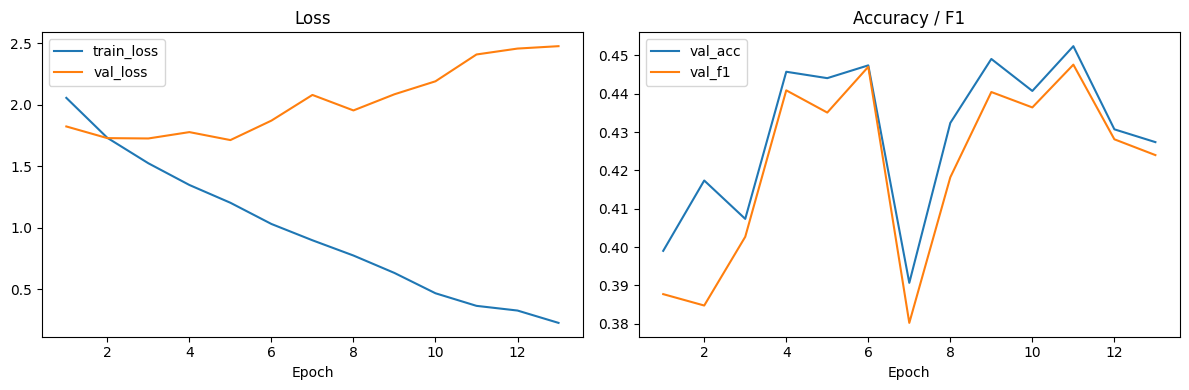

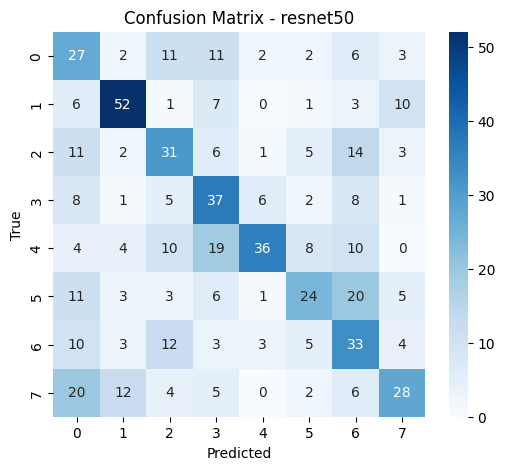

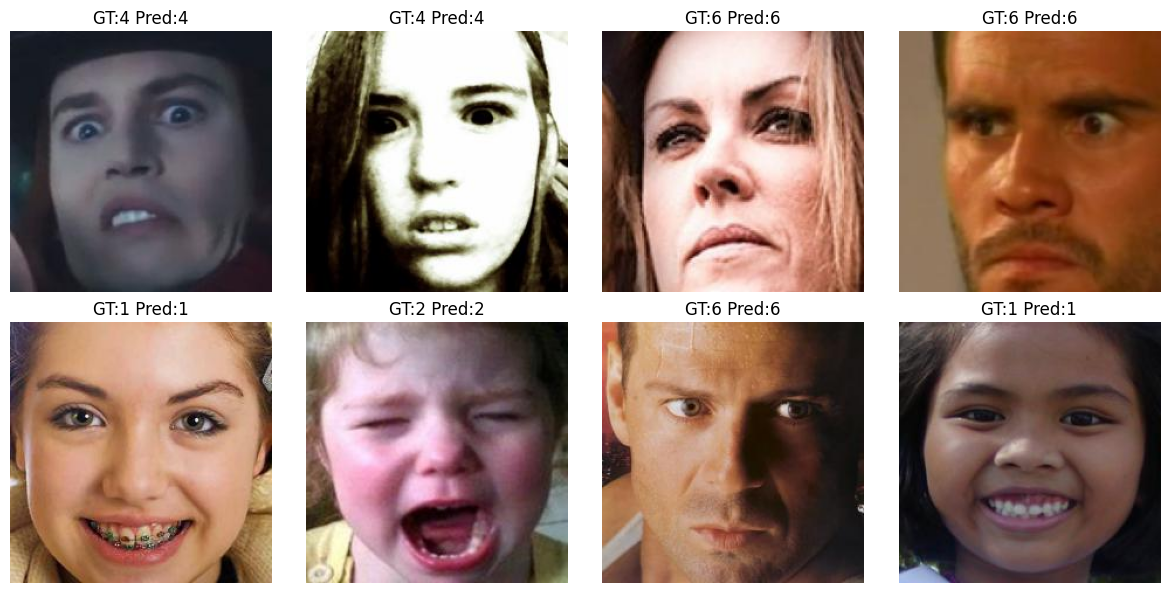

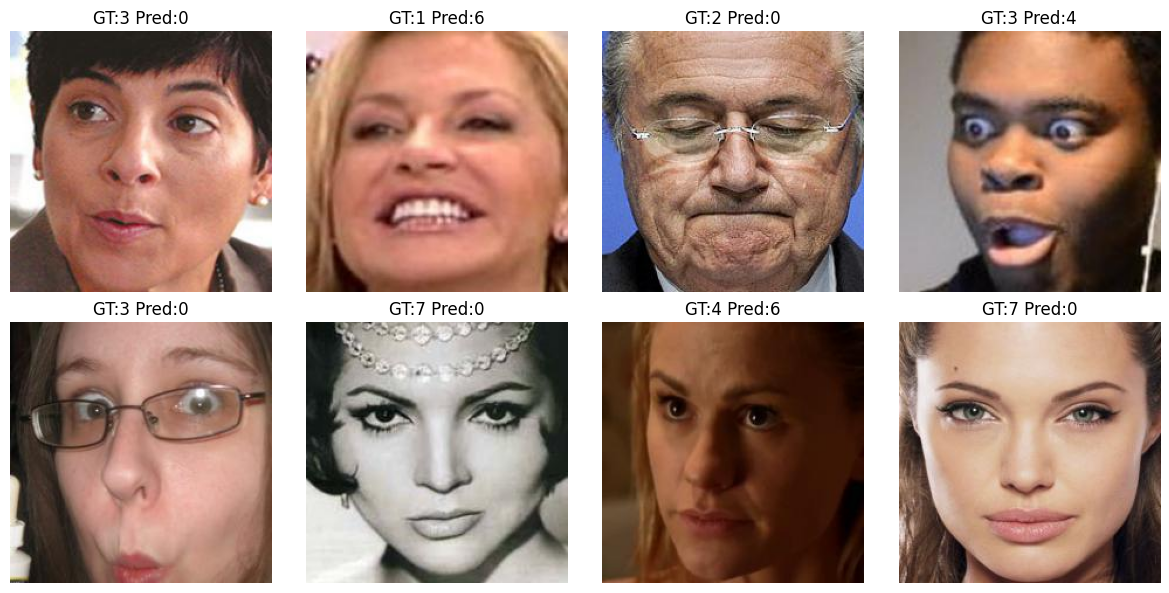


==== Training densenet121 ====
  Batch 21/213 - Loss: 2.2724
  Batch 42/213 - Loss: 2.3148
  Batch 63/213 - Loss: 2.1278
  Batch 84/213 - Loss: 2.1666
  Batch 105/213 - Loss: 2.0968
  Batch 126/213 - Loss: 2.1993
  Batch 147/213 - Loss: 2.0896
  Batch 168/213 - Loss: 2.1998
  Batch 189/213 - Loss: 2.2245
  Batch 210/213 - Loss: 1.7136
Epoch 001: val_f1=0.316 val_ccc=0.251 val_rmse=0.421 lr=3.0e-04
  Batch 21/213 - Loss: 1.8512
  Batch 42/213 - Loss: 1.5790
  Batch 63/213 - Loss: 1.4480
  Batch 84/213 - Loss: 1.5784
  Batch 105/213 - Loss: 1.4891
  Batch 126/213 - Loss: 1.8639
  Batch 147/213 - Loss: 1.7718
  Batch 168/213 - Loss: 1.3541
  Batch 189/213 - Loss: 1.5709
  Batch 210/213 - Loss: 2.2007
Epoch 002: val_f1=0.360 val_ccc=0.373 val_rmse=0.391 lr=3.0e-04
  Batch 21/213 - Loss: 1.9825
  Batch 42/213 - Loss: 1.2930
  Batch 63/213 - Loss: 1.6279
  Batch 84/213 - Loss: 1.6843
  Batch 105/213 - Loss: 1.6206
  Batch 126/213 - Loss: 1.9983
  Batch 147/213 - Loss: 1.7292
  Batch 168/213

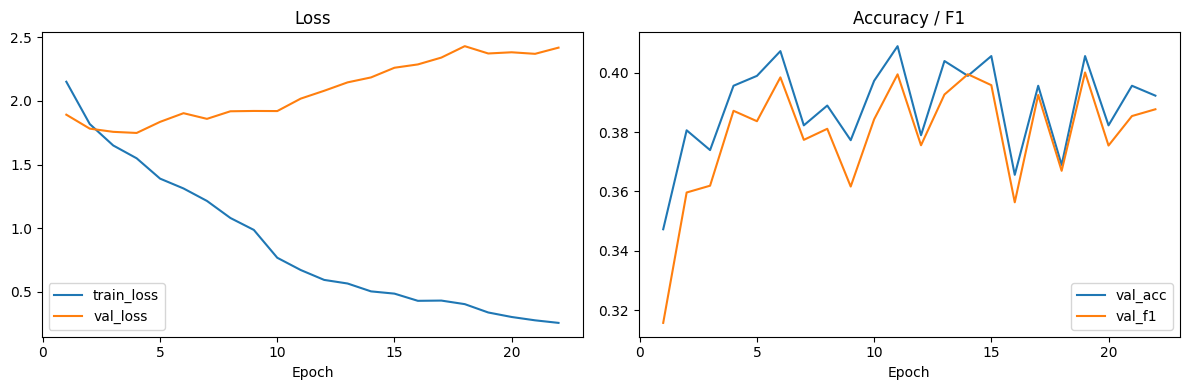

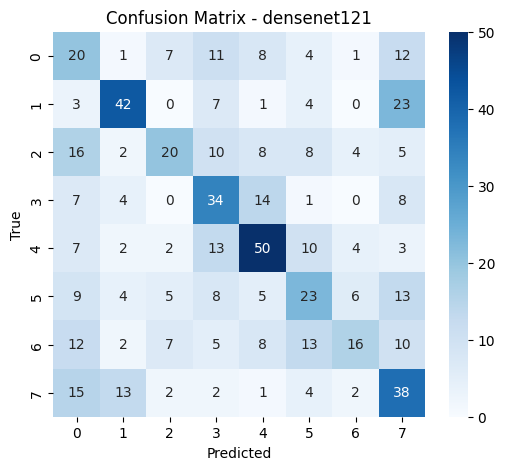

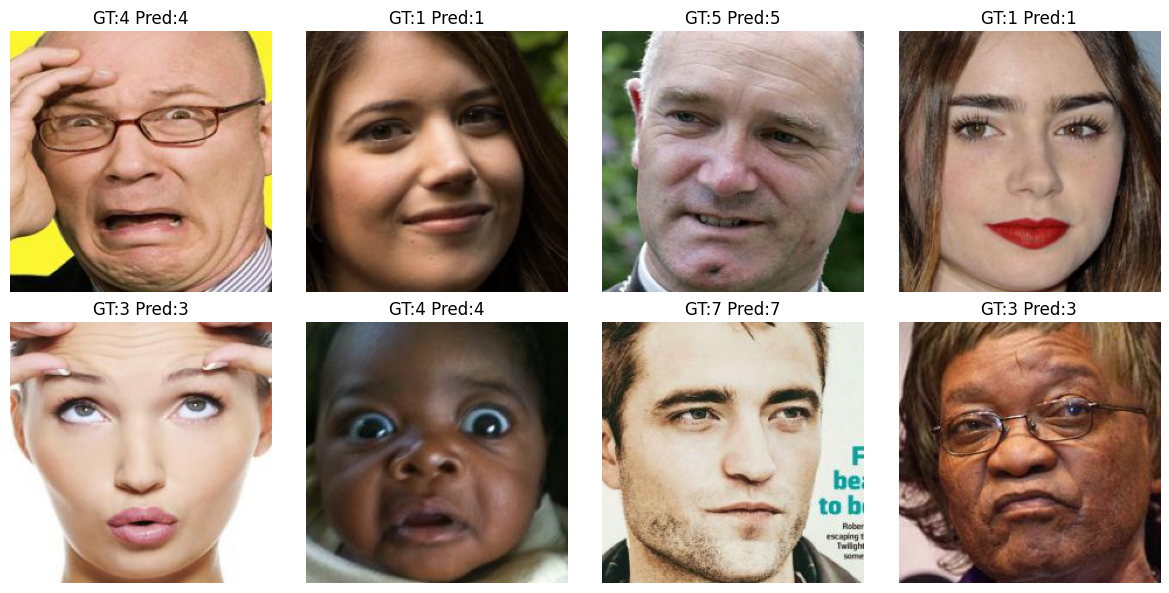

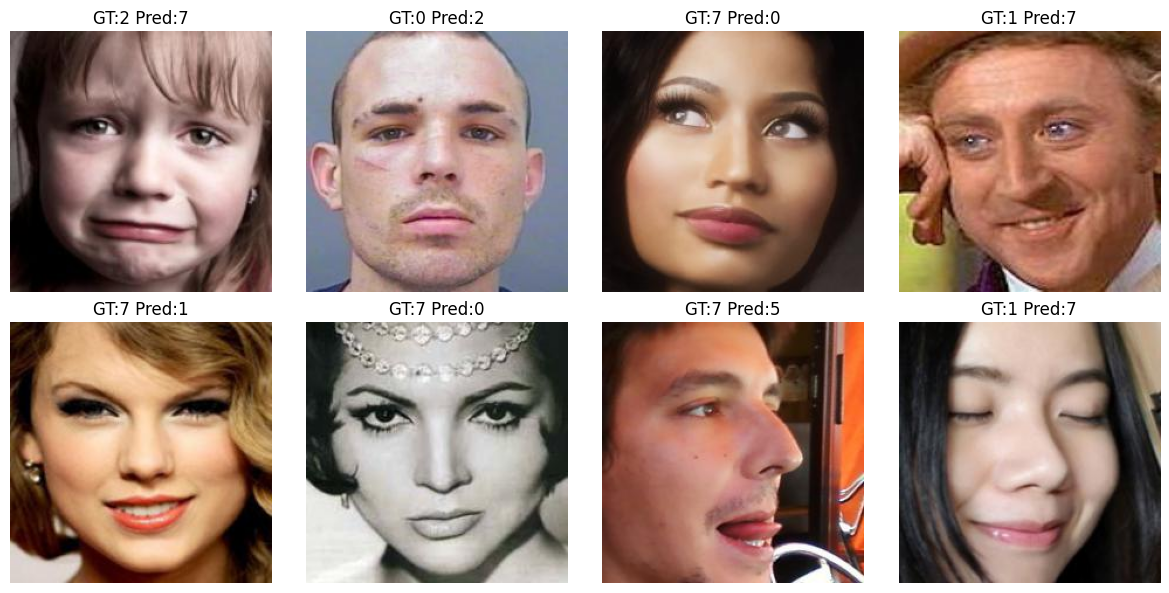

In [8]:
# Run baselines and compare

if train_loader is None or val_loader is None:
    print("Cannot run training: DataLoaders are not available.")
    print("Please fix the manifest building issues first.")
else:
    results_summary = []

    for model_name in ['resnet50', 'densenet121']:
        print(f"\n==== Training {model_name} ====")
        model, history, final_val = fit_model(model_name, train_loader, val_loader)
        plot_history(history, model_name)
        show_confusion_matrix(final_val['y_true'], final_val['y_pred'], model_name)
        show_sample_predictions(val_df, final_val['y_true'], final_val['y_pred'], correct=True, k=8)
        show_sample_predictions(val_df, final_val['y_true'], final_val['y_pred'], correct=False, k=8)

        results_summary.append({
            'model': model_name,
            'acc': final_val['acc'],
            'f1': final_val['f1'],
            'kappa': final_val['kappa'],
            'alpha': final_val['alpha'],
            'auc': final_val['auc'],
            'pr_auc': final_val['pr_auc'],
            'rmse_mean': final_val['rmse_mean'],
            'pear_mean': final_val['pear_mean'],
            'sagr_mean': final_val['sagr_mean'],
            'ccc_mean': final_val['ccc_mean'],
        })

    results_df = pd.DataFrame(results_summary)
    results_df.to_csv(OUTPUT_DIR / 'baseline_results.csv', index=False)
    results_df



==== Training custom CNN ====
  Batch 21/213 - Loss: 2.2363
  Batch 42/213 - Loss: 2.2604
  Batch 63/213 - Loss: 2.3690
  Batch 84/213 - Loss: 2.2424
  Batch 105/213 - Loss: 2.2979
  Batch 126/213 - Loss: 2.2843
  Batch 147/213 - Loss: 2.1383
  Batch 168/213 - Loss: 2.2444
  Batch 189/213 - Loss: 2.2855
  Batch 210/213 - Loss: 2.2531
Epoch 001: val_f1=0.095 val_ccc=-0.003 val_rmse=0.423 lr=3.0e-04
  Batch 21/213 - Loss: 2.3258
  Batch 42/213 - Loss: 2.3075
  Batch 63/213 - Loss: 2.4214
  Batch 84/213 - Loss: 2.2543
  Batch 105/213 - Loss: 2.2176
  Batch 126/213 - Loss: 2.2812
  Batch 147/213 - Loss: 2.2840
  Batch 168/213 - Loss: 2.2871
  Batch 189/213 - Loss: 2.2519
  Batch 210/213 - Loss: 2.2232
Epoch 002: val_f1=0.119 val_ccc=0.020 val_rmse=0.424 lr=3.0e-04
  Batch 21/213 - Loss: 2.2842
  Batch 42/213 - Loss: 2.3081
  Batch 63/213 - Loss: 2.2984
  Batch 84/213 - Loss: 2.3149
  Batch 105/213 - Loss: 2.2829
  Batch 126/213 - Loss: 2.2336
  Batch 147/213 - Loss: 2.3516
  Batch 168/213

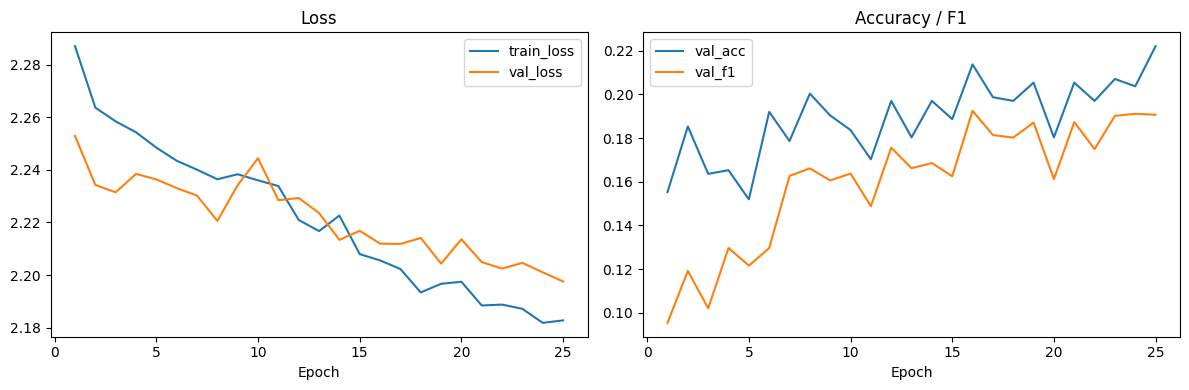

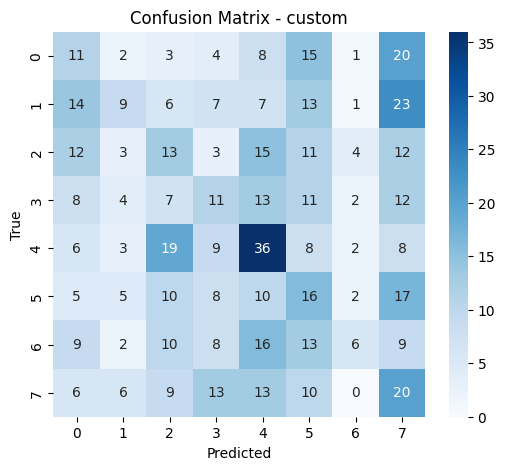

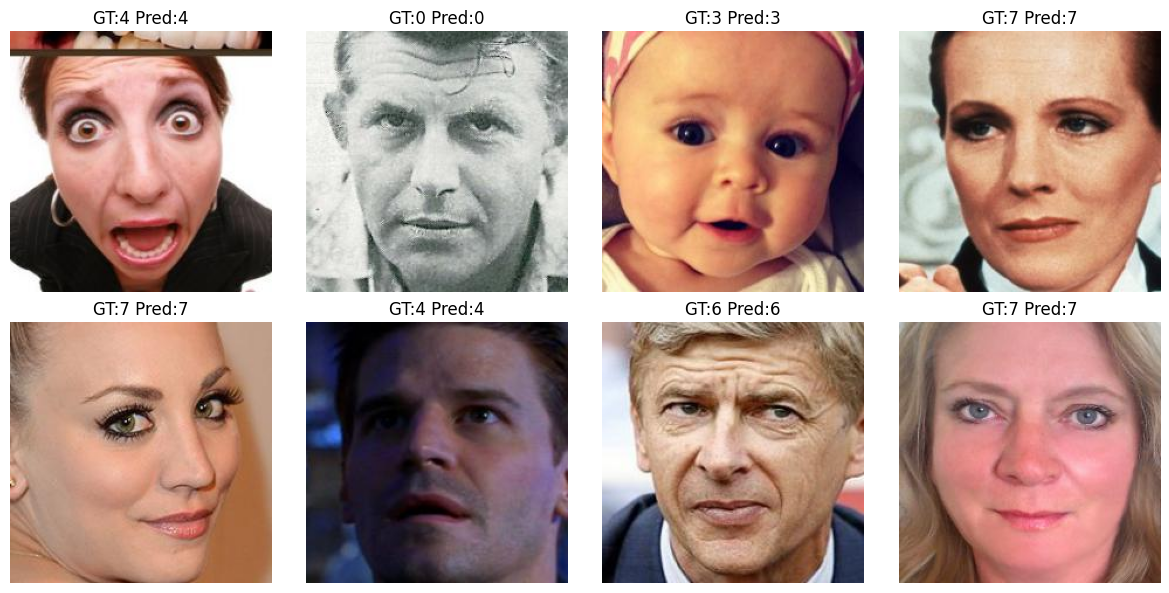

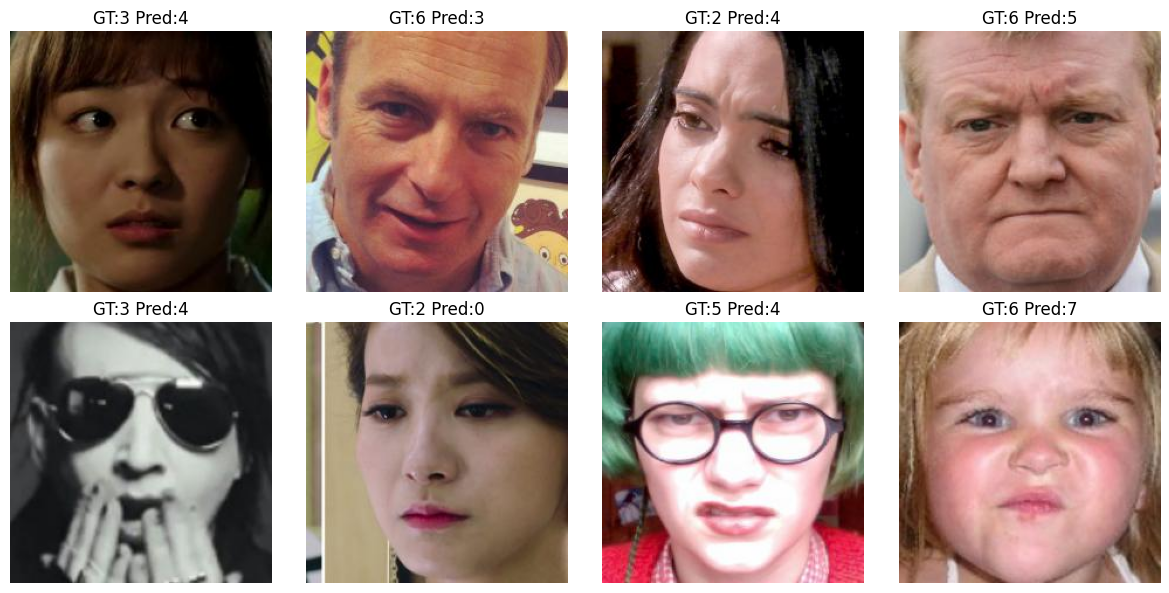

In [9]:
# Optional: Train Custom CNN

if train_loader is None or val_loader is None:
    print("Cannot run custom CNN training: DataLoaders are not available.")
    print("Please fix the manifest building issues first.")
else:
    print("\n==== Training custom CNN ====")
    model, history, final_val = fit_model('custom', train_loader, val_loader)
    plot_history(history, 'custom')
    show_confusion_matrix(final_val['y_true'], final_val['y_pred'], 'custom')
    show_sample_predictions(val_df, final_val['y_true'], final_val['y_pred'], correct=True, k=8)
    show_sample_predictions(val_df, final_val['y_true'], final_val['y_pred'], correct=False, k=8)

    # Append to summary if baselines already ran
    try:
        results_summary.append({
            'model': 'custom',
            'acc': final_val['acc'],
            'f1': final_val['f1'],
            'kappa': final_val['kappa'],
            'alpha': final_val['alpha'],
            'auc': final_val['auc'],
            'pr_auc': final_val['pr_auc'],
            'rmse_mean': final_val['rmse_mean'],
            'pear_mean': final_val['pear_mean'],
            'sagr_mean': final_val['sagr_mean'],
            'ccc_mean': final_val['ccc_mean'],
        })
        results_df = pd.DataFrame(results_summary)
        results_df.to_csv(OUTPUT_DIR / 'baseline_results.csv', index=False)
        results_df
    except NameError:
        pass


In [10]:
# Test the fixed annotation loading
print("Testing annotation loading with sample files...")
test_files = [
    ('Dataset/Dataset/annotations/0_exp.npy', 'expression'),
    ('Dataset/Dataset/annotations/0_val.npy', 'valence'),
    ('Dataset/Dataset/annotations/0_aro.npy', 'arousal')
]

for file_path, label_type in test_files:
    try:
        value = load_single_annotation(Path(file_path))
        print(f"{label_type}: {value}")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

print("\nManifest building test:")
test_manifest = build_manifest(IMAGES_DIR, ANN_DIR)
print(f"Test manifest has {len(test_manifest)} samples")
if len(test_manifest) > 0:
    print("Sample manifest entries:")
    print(test_manifest.head())


Testing annotation loading with sample files...
expression: 0.0
valence: -0.176846
arousal: -0.0776398

Manifest building test:
Test manifest has 3999 samples
Sample manifest entries:
                        image_path  expression   valence   arousal
0     Dataset\Dataset\images\0.jpg           0 -0.176846 -0.077640
1     Dataset\Dataset\images\1.jpg           0 -0.367789  0.183895
2    Dataset\Dataset\images\10.jpg           7 -0.648471  0.658149
3   Dataset\Dataset\images\100.jpg           3  0.150794  0.666667
4  Dataset\Dataset\images\1001.jpg           0 -0.135501  0.004839


### Short Report Helper

- Network details: architectures used (`ResNet50`, `DenseNet121`, optional `CustomCNN`), parameters frozen/unfrozen, heads, loss weights, optimizer, scheduler, early stopping.
- Transfer learning details: which layers frozen, which fine-tuned, rationale (ImageNet pretrained features transfer to facial patterns).
- Training settings: batch size, epochs, LR, weight decay, augmentations (flip, rotation, color jitter).
- Metrics rationale:
  - Accuracy/F1: overall and balanced performance across 8 expressions.
  - Cohen’s Kappa/Krippendorff’s Alpha: agreement beyond chance.
  - AUC/PR-AUC: probability ranking, robustness under class imbalance.
  - RMSE: magnitude of VA error.
  - Pearson r: linear correlation of VA dynamics.
  - SAGR: sign agreement critical for affect polarity.
  - CCC: agreement in both correlation and scale.
- Training graphs: included per model.
- Qualitative samples: shown for correct and incorrect predictions.
- Comparison table: see `results_df`.

Instructions: After running experiments, export this notebook as PDF with naming convention: `RollNo_Name_Assignment1_FER_VA.pdf`.
